Shape: (7043, 21)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

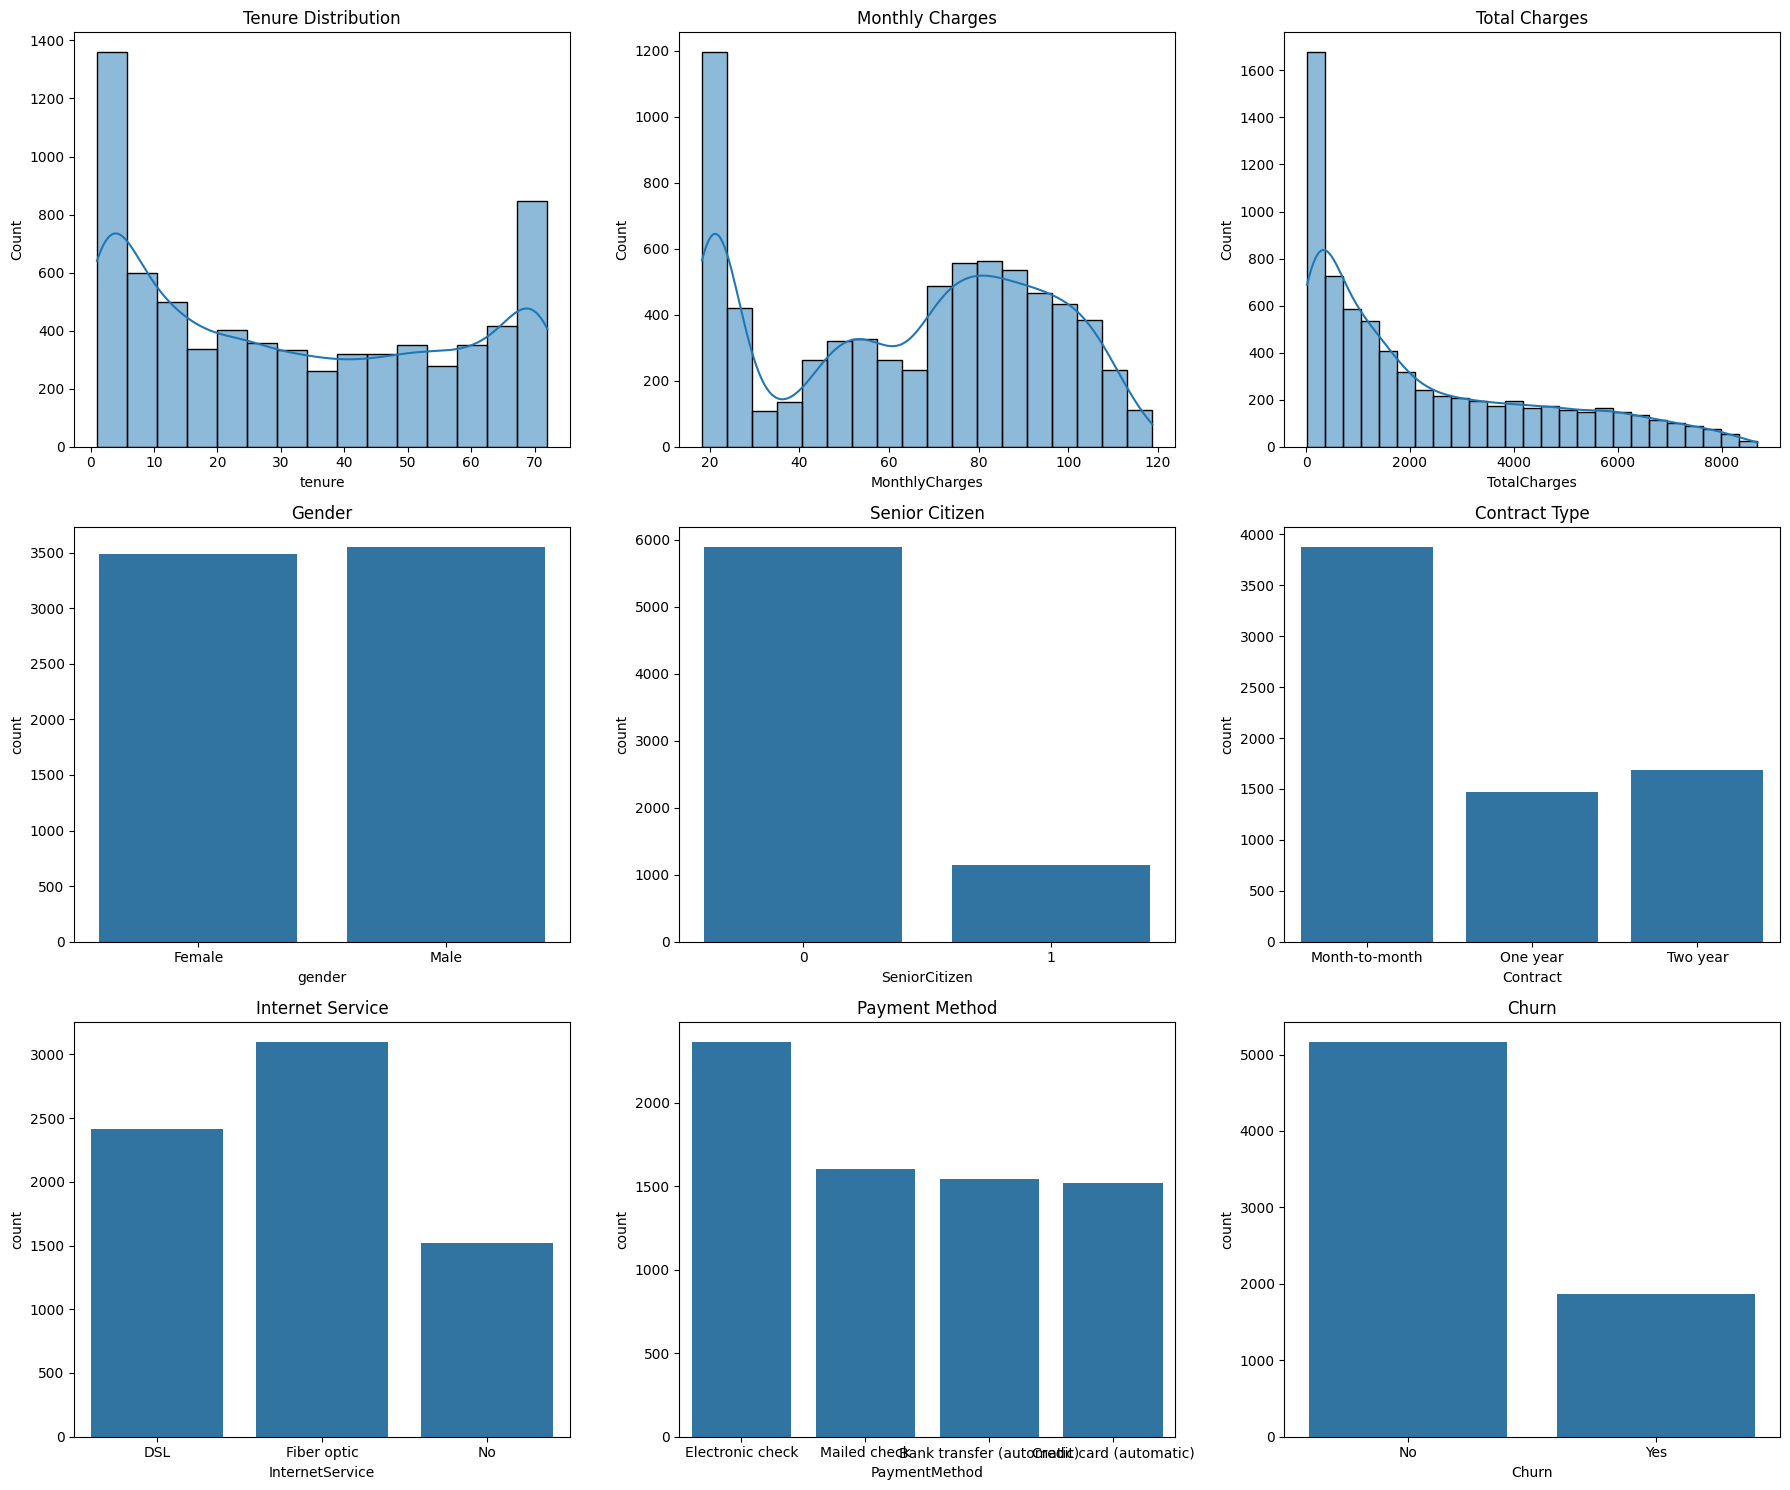

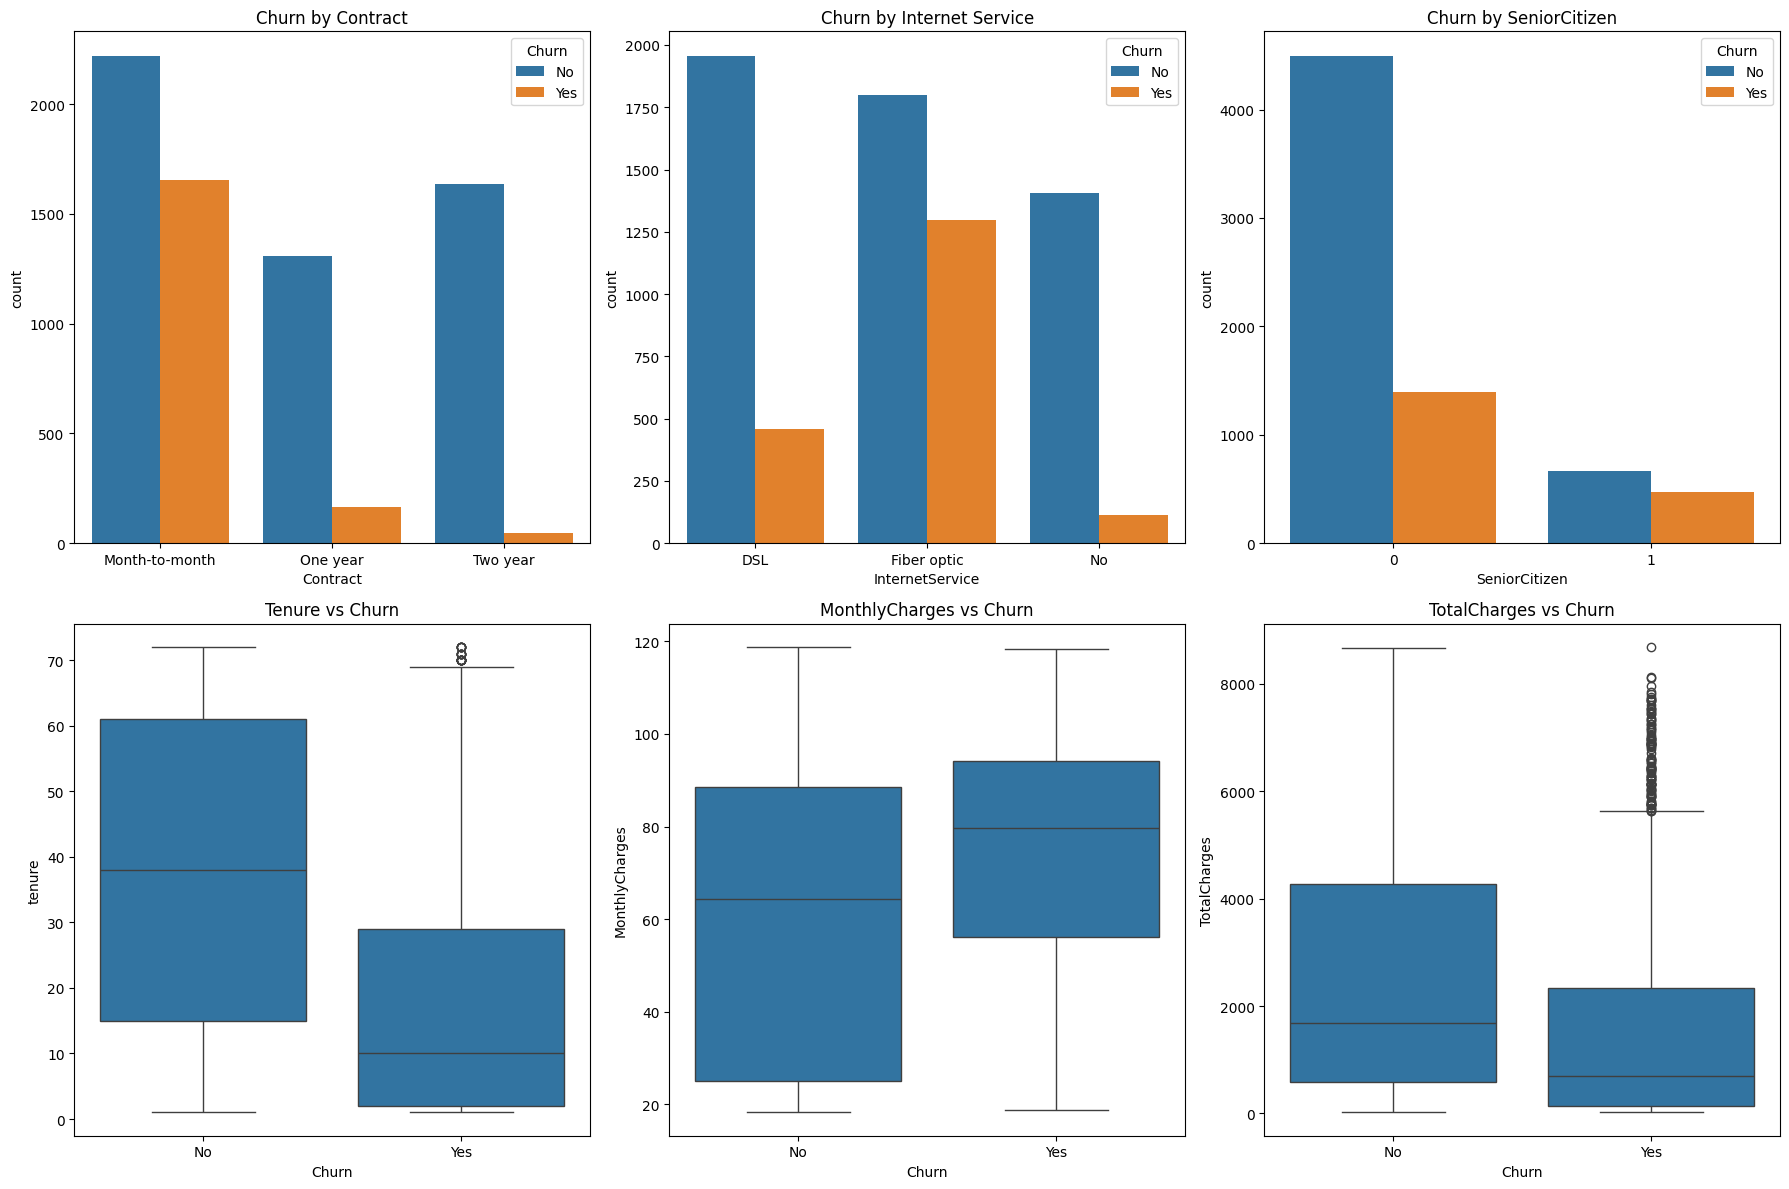


=== Churn Rate by gender ===
Churn         No       Yes
gender                    
Female  0.730405  0.269595
Male    0.737954  0.262046

=== Churn Rate by SeniorCitizen ===
Churn                No       Yes
SeniorCitizen                    
0              0.763497  0.236503
1              0.583187  0.416813

=== Churn Rate by Partner ===
Churn          No       Yes
Partner                    
No       0.670239  0.329761
Yes      0.802829  0.197171

=== Churn Rate by Dependents ===
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.844688  0.155312

=== Churn Rate by Contract ===
Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887228  0.112772
Two year        0.971513  0.028487

=== Churn Rate by InternetService ===
Churn                  No       Yes
InternetService                    
DSL              0.810017  0.189983
Fiber optic      0.581072  0.41892

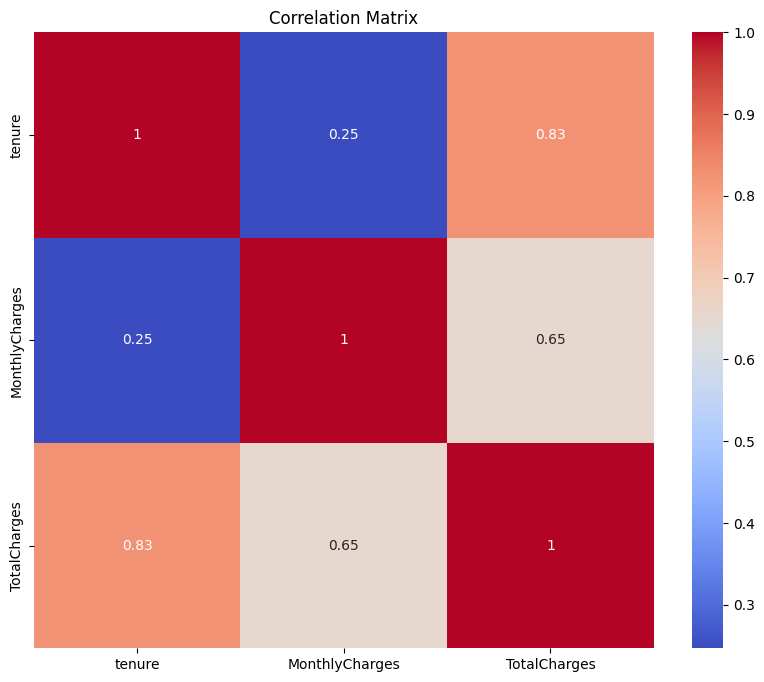

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Chuyển TotalCharges sang numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)

print("\nChurn Rate:", df['Churn'].value_counts(normalize=True))

# ====================== 2. Univariate Analysis ======================
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Numerical features
sns.histplot(df['tenure'], kde=True, ax=axes[0,0]).set_title('Tenure Distribution')
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0,1]).set_title('Monthly Charges')
sns.histplot(df['TotalCharges'], kde=True, ax=axes[0,2]).set_title('Total Charges')

# Categorical
sns.countplot(data=df, x='gender', ax=axes[1,0]).set_title('Gender')
sns.countplot(data=df, x='SeniorCitizen', ax=axes[1,1]).set_title('Senior Citizen')
sns.countplot(data=df, x='Contract', ax=axes[1,2]).set_title('Contract Type')

sns.countplot(data=df, x='InternetService', ax=axes[2,0]).set_title('Internet Service')
sns.countplot(data=df, x='PaymentMethod', ax=axes[2,1]).set_title('Payment Method')
sns.countplot(data=df, x='Churn', ax=axes[2,2]).set_title('Churn')

plt.tight_layout()
plt.savefig('../reports/figures/univariate_analysis.png')
plt.show()

# ====================== 3. Bivariate Analysis (vs Churn) ======================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0,0]).set_title('Churn by Contract')
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0,1]).set_title('Churn by Internet Service')
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=axes[0,2]).set_title('Churn by SeniorCitizen')

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1,0]).set_title('Tenure vs Churn')
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1,1]).set_title('MonthlyCharges vs Churn')
sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[1,2]).set_title('TotalCharges vs Churn')

plt.tight_layout()
plt.savefig('../reports/figures/bivariate_analysis.png')
plt.show()

# ====================== 4. Churn Rate by Categories ======================
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 
            'InternetService', 'OnlineSecurity', 'TechSupport', 'PaymentMethod']

for col in cat_cols:
    print(f"\n=== Churn Rate by {col} ===")
    print(df.groupby(col)['Churn'].value_counts(normalize=True).unstack())

# ====================== 5. Correlation (Numerical) ======================
plt.figure(figsize=(10, 8))
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('../reports/figures/correlation.png')
plt.show()




